<a href="https://www.kaggle.com/code/riyagandhi224/sales-revenue-prediction?scriptVersionId=297543453" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

**Student Name:  Riya Swapnil Gandhi**

**Project Title: Sales Revenue Prediction**

**1. Business Understanding**

**Problem Statement**

The main problem we are addressing is predicting future sales revenue based on advertising spending and other influencing factors. Businesses invest in marketing channels like TV, Radio, and Social Media but need insights into how these investments impact sales.

**This project aims to:**

Analyze sales data

Identify factors affecting revenue

Build a Linear Regression model

Predict future sales amount

**2.Data Understanding**

In [1]:
import pandas as pd

# Load dataset
df = pd.read_csv("/kaggle/input/sales-prediction-dataset/sales data file.csv")

In [2]:
df

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9
...,...,...,...,...
195,38.2,3.7,13.8,7.6
196,94.2,4.9,8.1,14.0
197,177.0,9.3,6.4,14.8
198,283.6,42.0,66.2,25.5


In [3]:
# Display top 5 rows
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [4]:
# Display bottom 5 rows
df.tail()

,TV,Radio,Newspaper,Sales
195,38.2,3.7,13.8,7.6
196,94.2,4.9,8.1,14.0
197,177.0,9.3,6.4,14.8
198,283.6,42.0,66.2,25.5
199,232.1,8.6,8.7,18.4


Summary Statistics

In [5]:
#summary statistics
df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,15.130500
std,85.854236,14.846809,21.778621,5.283892
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,11.000000
50%,149.750000,22.900000,25.750000,16.000000
75%,218.825000,36.525000,45.100000,19.050000
max,296.400000,49.600000,114.000000,27.000000


Correlaion Analysis

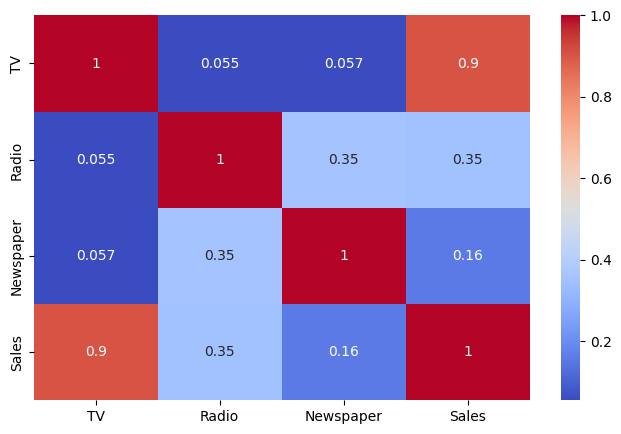

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df.corr()

plt.figure(figsize=(8,5))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

The correlation matrix shows the relationship between advertising channels (TV, Radio, Newspaper) and Sales.

TV and Sales have a very strong positive correlation (~0.9), which means TV advertising has the highest impact on sales.

Radio and Sales show a moderate positive correlation (~0.35), indicating radio ads also contribute to sales but less than TV.

Newspaper and Sales have a weak correlation (~0.16), so newspaper advertising has the least influence on sales.

TV with Radio/Newspaper has very low correlation (~0.05), meaning these channels operate independently.

Radio and Newspaper have a moderate relationship (~0.35).

**3.Data Preparation**

Data Cleaning

In [7]:
#check for missing values
df.isnull()

,TV,Radio,Newspaper,Sales
0,False,False,False,False
1,False,False,False,False
2,False,False,False,False
3,False,False,False,False
4,False,False,False,False
...,...,...,...,...
195,False,False,False,False
196,False,False,False,False
197,False,False,False,False
198,False,False,False,False


In [8]:
df.isnull().sum()

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

In [9]:
# Fill missing values
# Here no missing values are present if present we can clean them by using
df.fillna(df.mean(), inplace=True)
# Outliers can be removed using IQR if required.

**Machine Learning Task**

**Type**: Regression

**Independent variables:**

TV

Radio

Newspaper

**Dependent variable:**

Sales

In [10]:
X = df[['TV','Radio','Newspaper']]
y = df['Sales']

**Train-Test Split**

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

**4. Data Preprocessing**
Missing Values :Not present

//if missing values would have present , they would have been handled by
Feature Engineering

Creating interaction terms if needed

Removing irrelevant columns

**Scaling / Normalization**

In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


**5. Exploratory Data Analysis (EDA)**

**Visualizations**

**Histogram**

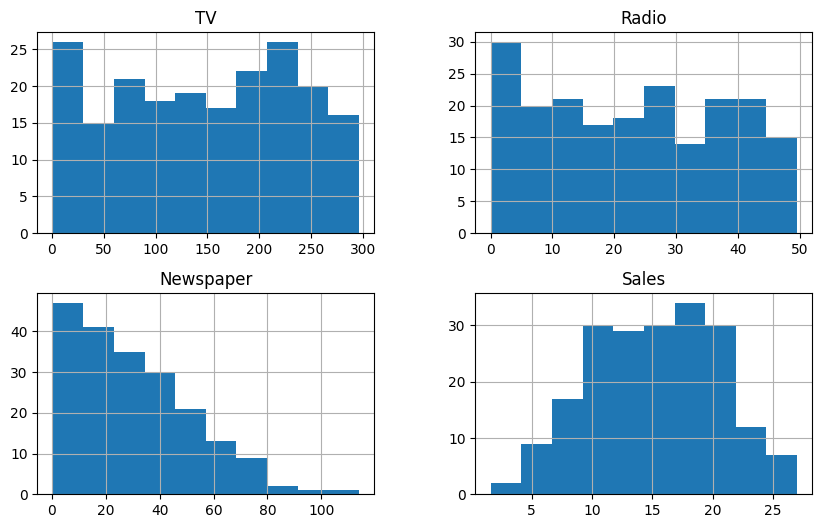

In [13]:
df.hist(figsize=(10,6))
plt.show()

**Scatter Plot**

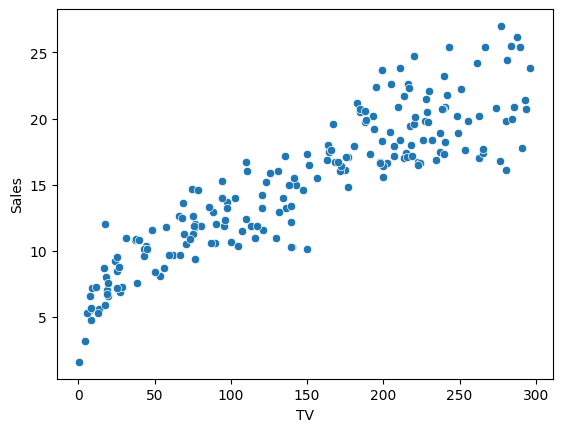

In [14]:
sns.scatterplot(x='TV', y='Sales', data=df)
plt.show()

This Scattered plot shows relation between TVadvertising expenditure and Sales

**Outliers Detections**

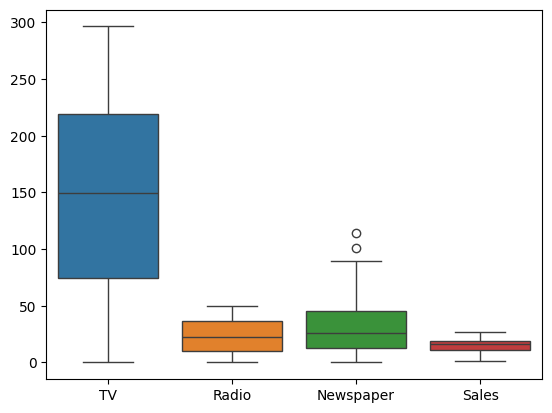

In [15]:
sns.boxplot(data=df)
plt.show()

Outliers handled using:

IQR method

Removing extreme values

In [16]:
import numpy as np

def handle_outliers_iqr(df, column_name):
    Q1 = df[column_name].quantile(0.25)
    Q3 = df[column_name].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Method 1: Remove outliers
    df_no_outliers = df[(df[column_name] >= lower_bound) & (df[column_name] <= upper_bound)]
    print(f"Original shape: {df.shape}, Shape after removing outliers: {df_no_outliers.shape}")
    
    # Method 2: Cap or winsorize outliers (replace with bound values)
    df[column_name] = np.where(df[column_name] > upper_bound, upper_bound, 
                               np.where(df[column_name] < lower_bound, lower_bound, df[column_name]))
    print(f"Shape after capping outliers: {df.shape}")
    
    return df_no_outliers, df

df_cleaned_remove, df_cleaned_cap = handle_outliers_iqr(df.copy(), 'Newspaper')

Original shape: (200, 4), Shape after removing outliers: (198, 4)
Shape after capping outliers: (200, 4)


**6. Model Selection**
**Model Choice:** Linear Regression

**Reason:**

Predict continuous values

Simple & interpretable

Best for business forecasting

In [17]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

Ensemble Methods (Optional)

We can also use:

Random Forest Regressor

Gradient Boosting

But Linear Regression is baseline model.

**7. Prediction**

Model Evaluation

In [18]:
from sklearn.metrics import mean_absolute_error, r2_score

y_pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 1.2748262109549349
R2 Score: 0.9059011844150825


Future Sales Prediction

In [19]:
import warnings
warnings.filterwarnings("ignore")
# Example prediction
new_data = [[230, 40, 20]]  # TV, Radio, Newspaper spend

new_data = scaler.transform(new_data)

prediction = model.predict(new_data)

print("Predicted Sales:", prediction)

Predicted Sales: [21.37580613]


**Final Outcome**

Built Linear Regression model

Identified marketing factors affecting sales

Predicted future revenue

Helps businesses:

Optimize advertising budget

Increase profitability

Forecast demand